#### STEP 1: DATA LOADING

In [58]:
import pandas as pd
df=pd.read_csv(r"C:\Users\KOMAL\Desktop\netflix.csv")

In [59]:
df.head()

,date,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
0,1/2/2014,52.401428,52.511429,51.542858,51.831429,12325600,34.729664,49.183584,-89.573201,-131.288579,50.112828,50.235157,46.385428,46.650698,0.751929,52.607357,1.052857,1.161182,1.247748,51.871429
1,1/3/2014,52.000000,52.495712,51.842857,51.871429,10817100,35.587886,49.457208,-65.820581,-103.026189,50.228771,50.299327,46.537571,46.754726,0.624259,52.656143,0.664283,1.090197,1.206072,51.367142
2,1/6/2014,51.889999,52.044285,50.475716,51.367142,15501500,29.820674,46.087900,-121.472559,-139.640566,50.312571,50.341203,46.680971,46.846621,0.476890,52.666928,1.568569,1.158535,1.231965,48.500000
3,1/7/2014,49.684284,49.698570,48.152859,48.500000,36167600,14.371863,32.522091,-206.762171,-238.029120,50.336228,50.268997,46.791957,46.879558,0.127277,52.560214,3.214283,1.452214,1.373559,48.712856
4,1/8/2014,48.104286,49.425713,48.074287,48.712856,20001100,18.049045,34.073549,-117.836707,-180.766801,50.373257,50.207969,46.917071,46.916075,-0.131106,52.455357,1.351426,1.437815,1.371978,48.150002


#### Extracting the column useful for stock price prediction

In [60]:
x=df["open"]

In [24]:
x=x[:-10]

In [25]:
x

0        52.401428
1        52.000000
2        51.889999
3        49.684284
4        48.104286
           ...    
2501    450.760010
2502    459.359985
2503    465.230011
2504    461.980011
2505    480.359985
Name: open, Length: 2506, dtype: float64

#### Storing the last 10 records for the comnparison in last i.e. to check how well model is giving prediction

In [26]:
y=df["open"]
y=y[-10:]

In [27]:
y

2506    467.299988
2507    476.299988
2508    488.399994
2509    492.000000
2510    492.660004
2511    494.000000
2512    489.390015
2513    491.239990
2514    492.000000
2515    490.369995
Name: open, dtype: float64

#### Applying MINMAX SCALING 

In [28]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
x=np.array(x).reshape(len(x),1)
m=MinMaxScaler()
x=m.fit_transform(x)
x

array([[0.01203517],
       [0.01141544],
       [0.01124562],
       ...,
       [0.64936785],
       [0.64435044],
       [0.67272579]])

#### Converting data into time series format with timestamp of 50

In [29]:
x_stock=[]
y_stock=[]
for i in range(30,len(x)):
    x_stock.append(x[i-30:i])
    y_stock.append(x[i])

In [30]:
print(x_stock)

[array([[0.01203517],
       [0.01141544],
       [0.01124562],
       [0.0078404 ],
       [0.00540116],
       [0.00651272],
       [0.0056967 ],
       [0.00416611],
       [0.00643993],
       [0.00501962],
       [0.00356622],
       [0.00437342],
       [0.00440871],
       [0.00380662],
       [0.01657621],
       [0.01575578],
       [0.01657401],
       [0.01523529],
       [0.02004318],
       [0.02092096],
       [0.01986454],
       [0.02197958],
       [0.02055706],
       [0.0200498 ],
       [0.02077099],
       [0.02231922],
       [0.02584574],
       [0.02596263],
       [0.02702566],
       [0.0250209 ]]), array([[0.01141544],
       [0.01124562],
       [0.0078404 ],
       [0.00540116],
       [0.00651272],
       [0.0056967 ],
       [0.00416611],
       [0.00643993],
       [0.00501962],
       [0.00356622],
       [0.00437342],
       [0.00440871],
       [0.00380662],
       [0.01657621],
       [0.01575578],
       [0.01657401],
       [0.01523529],
       [0.

In [31]:
print(y_stock)

[array([0.0275285]), array([0.02750645]), array([0.02633977]), array([0.02604864]), array([0.0278902]), array([0.02717783]), array([0.03038236]), array([0.03168358]), array([0.02990598]), array([0.03107267]), array([0.02843935]), array([0.03058527]), array([0.03126234]), array([0.03147186]), array([0.03127998]), array([0.03004493]), array([0.02875915]), array([0.02678306]), array([0.02811295]), array([0.02547081]), array([0.02557226]), array([0.02428869]), array([0.02373733]), array([0.02369322]), array([0.02511132]), array([0.02056588]), array([0.01472363]), array([0.01340256]), array([0.01296147]), array([0.01058178]), array([0.01086629]), array([0.00871376]), array([0.01178155]), array([0.01082659]), array([0.00952978]), array([0.00623483]), array([0.00613337]), array([0.00855497]), array([0.00931585]), array([0.00409333]), array([0.00455427]), array([0.00371399]), array([0.00414847]), array([0.00540778]), array([0.00817342]), array([0.01420093]), array([0.01113535]), array([0.00887

#### Coverting x_tock and y_stock into array

In [32]:
x_stock=np.array(x_stock)
y_stock=np.array(y_stock)

In [33]:
x_stock.shape,y_stock.shape

((2476, 30, 1), (2476, 1))

#### Building the LSTM model

In [34]:
import tensorflow 
from tensorflow.keras.layers import Dense,LSTM
from tensorflow.keras.models import Sequential

In [35]:
lstm=Sequential()
lstm.add(LSTM(units=64,input_shape=(x_stock.shape[1],x_stock.shape[2]),return_sequences=True))  # First lstm layer
lstm.add(LSTM(units=32))
lstm.add(Dense(units=1,activation="relu"))

C:\Users\KOMAL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
lstm.compile(optimizer="sgd",loss="mse")

In [38]:
history=lstm.fit(x_stock,y_stock,epochs=30,batch_size=20)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - loss: 0.0543
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0029
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0015
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0015
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0015
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0014
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.0016
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0013
Epoch 9/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0013
Epoch 10/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0015
Epoch 11/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0014
Epoch 12/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0012
Epoch 13/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0013
Epoch 14/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0013
Epoch 15/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4

#### Creating learning curve for loss

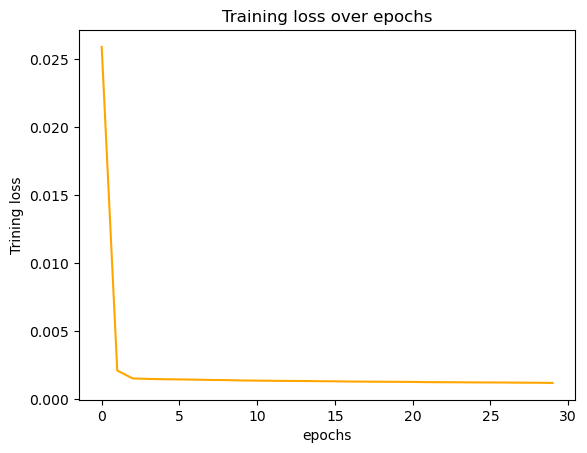

In [39]:
import matplotlib.pyplot as plt
training_loss=history.history["loss"]
plt.plot(training_loss,color="orange")
plt.title("Training loss over epochs")
plt.xlabel("epochs")
plt.ylabel("Trining loss")
plt.show()

#### Making prediction on seen data to know how well model performing on already seen data

In [40]:
y_pred=lstm.predict(x_stock)
y_pred

78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


array([[0.0236426 ],
       [0.02451309],
       [0.02536318],
       ...,
       [0.6572333 ],
       [0.65722543],
       [0.65716475]], dtype=float32)

#### Now , we will use Inverse transform
#### It is concept of making original form of data as it was before the transformation.


In [41]:
y_pred=m.inverse_transform(y_pred)

In [42]:
y_pred

array([[ 59.92007 ],
       [ 60.48393 ],
       [ 61.034565],
       ...,
       [470.3248  ],
       [470.3197  ],
       [470.28043 ]], dtype=float32)

In [43]:
y_stock=m.inverse_transform(y_stock)
y_stock

array([[ 62.437141],
       [ 62.422855],
       [ 61.667145],
       ...,
       [465.230011],
       [461.980011],
       [480.359985]])

#### Graph for comparison between y_pred and y_stock


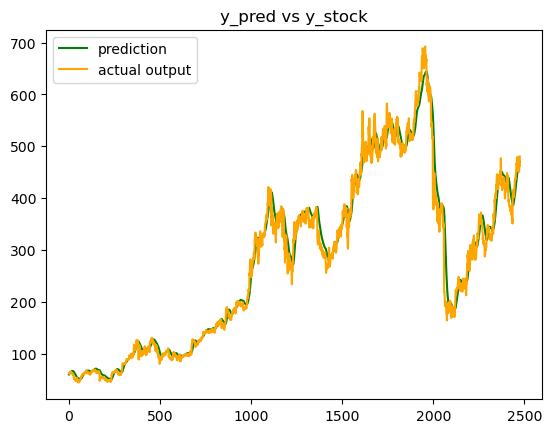

In [45]:
import matplotlib.pyplot as plt
plt.plot(y_pred,label="prediction",color="green")
plt.plot(y_stock,label="actual output",color="orange")
plt.title("y_pred vs y_stock")
plt.legend()
plt.show()

#### to predict stock on 30 dec 2023 -->
##### We need to find the last 30 days i.e. 1 dec 2023 to 29 dec 2023 record as timestamp=30 to predict next stock on 31 dec 2016

In [47]:
df.tail()

,date,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
2511,12/22/2023,494.000000,496.019989,485.450012,486.760010,2701100,61.286700,62.629263,42.406864,87.904519,443.339798,451.651874,425.729399,432.159057,11.455084,471.507500,10.569977,11.260790,10.724453,491.190002
2512,12/26/2023,489.390015,491.480011,486.380005,491.190002,2034500,65.324458,64.613544,31.476352,76.722042,446.049999,453.202389,426.331299,433.327986,11.575034,472.108499,5.100006,10.380678,10.322707,491.790009
2513,12/27/2023,491.239990,494.019989,489.250000,491.790009,2561300,65.886676,64.885498,54.412289,74.696489,448.669399,454.715629,426.933199,434.485650,11.584966,472.748000,4.769989,9.579151,9.926084,490.510010
2514,12/28/2023,492.000000,492.890015,489.070007,490.510010,1710500,63.331047,63.759744,-14.020755,61.870371,451.365199,456.119330,427.430699,435.595043,11.358617,473.414000,3.820008,8.756417,9.489936,486.880005
2515,12/29/2023,490.369995,492.230011,481.940002,486.880005,2739500,56.127883,60.551251,-157.815293,32.706720,454.178999,457.325631,427.916499,436.610587,10.762262,474.059500,10.290009,8.975501,9.547084,468.500000


In [63]:
l=x[-30:]  ## last 30 values 
l

2486    463.000000
2487    466.950012
2488    465.399994
2489    472.630005
2490    476.799988
2491    477.109985
2492    479.029999
2493    478.109985
2494    479.000000
2495    475.309998
2496    473.170013
2497    460.989990
2498    450.700012
2499    460.000000
2500    450.850006
2501    450.760010
2502    459.359985
2503    465.230011
2504    461.980011
2505    480.359985
2506    467.299988
2507    476.299988
2508    488.399994
2509    492.000000
2510    492.660004
2511    494.000000
2512    489.390015
2513    491.239990
2514    492.000000
2515    490.369995
Name: open, dtype: float64

#### To make prediction lstm, we need to provide the data in 3D


In [64]:
l=np.reshape(l,(1,30,1))

In [65]:
l.shape

(1, 30, 1)

In [66]:
dec_30=lstm.predict(l)
dec_30=m.inverse_transform(dec_30)
print(dec_30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
[[157.4411]]


#### Now , we will create function for predicting stock price for next 10 days

#### Predicting the stock price from 30 dec to 4 jan 2024

In [67]:
l=x[-30:] 
for i in range(10):
    next_day=lstm.predict(np.reshape(l,(1,30,1)))
    next_day=m.inverse_transform(next_day)
    print("Stock for ",i+1,"day:",next_day)
    l=l[1:]
    l=np.append(l, next_day)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Stock for  1 day: [[157.4411]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Stock for  2 day: [[170.32947]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Stock for  3 day: [[177.788]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Stock for  4 day: [[182.0966]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Stock for  5 day: [[184.24869]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Stock for  6 day: [[185.08173]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Stock for  7 day: [[185.11588]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Stock for  8 day: [[184.67744]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Stock for  9 day: [[183.97139]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Stock for  10 day: [[183.12587]]
